# EPC03 Mediana

Implemente dois algoritmos para obter a mediana de uma lista de elementos. Um dos algoritmos deve ser baseado no método força bruta e o outro no método diminuir para conquistar.

Os dois algoritmos devem ser implementados em python (sem utilizar nenhuma biblioteca externa). Eles devem receber como parâmetro uma lista de elementos e devem retornar a mediana da lista. 

Você deve implementar também um código que gere um gráfico comparando o desempenho dos algoritmos utilizando listas com diferentes tamanhos.

Você deve enviar o código dos algoritmos e do gráfico em um arquivo único no formato .ipypnb. Ao enviar o seu EPC, por favor, nomeie o seu arquivo para: EPC03-SeuNome.ipynb

In [161]:
from typing import List

In [162]:
def swap(list: List, pos1, pos2):
    list[pos1], list[pos2] = list[pos2], list[pos1]
    return list

In [163]:
def merge_sort(L):
    if len(L) <= 1:
        return L

    middle = len(L) // 2

    left = merge_sort(L[:middle])
    right = merge_sort(L[middle:])

    return merge(left, right)


def merge(left, right):
    result = []
    i = j = 0

    while i < len(left) and j < len(right):
        if left[i] <= right[j]:
            result.append(left[i])
            i += 1
        else:
            result.append(right[j])
            j += 1

    result.extend(left[i:])
    result.extend(right[j:])

    return result

In [164]:
def median_nlogn(L):
    #obs: implementei o merge_sort porque o order do python usa um algoritmo chamado timsort e tbm é otimizado!
    order_list = merge_sort(L)
    n = len(order_list)

    if n % 2 == 0:
        return (order_list[n//2 - 1] + order_list[n//2]) / 2
    else:
        return order_list[n//2]

In [165]:
def lomuto_partition(L:List, l, r):
    pivo = L[l]
    s = l
    for i in range(l + 1, r + 1):
        if L[i] < pivo:
            s = s + 1
            swap(L, s, i)
    swap(L,l,s)
    return s

In [166]:
import random

def quick_select(L: List, l, r, k) -> int:
    """
    obs: o pivo aleatório é melhor para o experimento, vide que diminui a probabilidade de que ocorra um balanceamento ruim. 
    Antes de adotar essa abordagem, os resultados não foram bons.
    """
    pivot_idx = random.randint(l, r)
    swap(L, l, pivot_idx)

    s = lomuto_partition(L, l, r)

    if s == k - 1:
        return L[s]
    elif s > k - 1:
        return quick_select(L, l, s - 1, k)
    else:
        return quick_select(L, s + 1, r, k)

In [167]:
def median_n(L:List):
    L = L.copy()
    n = len(L)

    if n % 2 == 1:
        # Lista ímpar o índice mediano é o (n/2) + 1
        return quick_select(L, 0, n-1, (n // 2) + 1)
    
    """
    Quando for par, é necessário dois quick-selects. Elemento menor (posição n/2) e lemento maior (posição (n/2)+1)
    """
    #copy porque lista é por referência
    lower = quick_select(L, 0, n-1, n//2)
    upper = quick_select(L.copy(), 0, n-1, (n//2) + 1)
    return (lower + upper) / 2

In [168]:
"""
Esse trecho coleta os dados para o experimento. É definido um número de rounds, para cada round é gerada uma lista aleatória para cada tamanho e o tempo de execução
de cada algoritmo é acumulado. Por fim os tempos são divididos pelo número de rounds, obtendo a média do tempo de cada algoritmo em 3 listas aleatórias 
diferentes para cada tamanho.
"""
import time
import random as py_random

DOMAIN = 1000000000 #1B

py_random.seed(31)

def executionTime(L, func):
    start = time.perf_counter()
    func(L)
    end = time.perf_counter()
    return end - start

#defines the algorithms to be processed
algorithms = [median_nlogn, median_n]

#defines the number of times each algorithm will be processed to find the average time
num_rounds = 3

sizes = [100000, 500000, 1000000, 1500000, 2000000]
mapSizeToTime = dict()
for size in sizes:
    for algorithm in algorithms:
        mapSizeToTime[f"{algorithm.__name__}##{size}"] = 0

for i in range(num_rounds):
    print(f"Starting round {i+1}")
    for size in sizes:
        L = py_random.sample(range(DOMAIN), size)
        for algorithm in algorithms:
            mapSizeToTime[f"{algorithm.__name__}##{size}"] += executionTime(L.copy(), algorithm)

for key in mapSizeToTime:
    mapSizeToTime[key] /= num_rounds

print("Finish data collection") 

Starting round 1
Starting round 2
Starting round 3
Finish data collection


In [169]:
#formata os dados do experimento para exibir
import pandas as pd
df = pd.DataFrame.from_dict(mapSizeToTime, orient='index',columns=['Time'])
df['Algorithm'] = [i.split("##")[0] for i in df.index]
df['Size'] = [int(i.split("##")[1]) for i in df.index]
df

,Time,Algorithm,Size
median_nlogn##100000,0.311784,median_nlogn,100000
median_n##100000,0.098628,median_n,100000
median_nlogn##500000,1.850451,median_nlogn,500000
median_n##500000,0.550459,median_n,500000
median_nlogn##1000000,4.284095,median_nlogn,1000000
median_n##1000000,1.197706,median_n,1000000
median_nlogn##1500000,6.289144,median_nlogn,1500000
median_n##1500000,1.761268,median_n,1500000
median_nlogn##2000000,8.601113,median_nlogn,2000000
median_n##2000000,2.416652,median_n,2000000


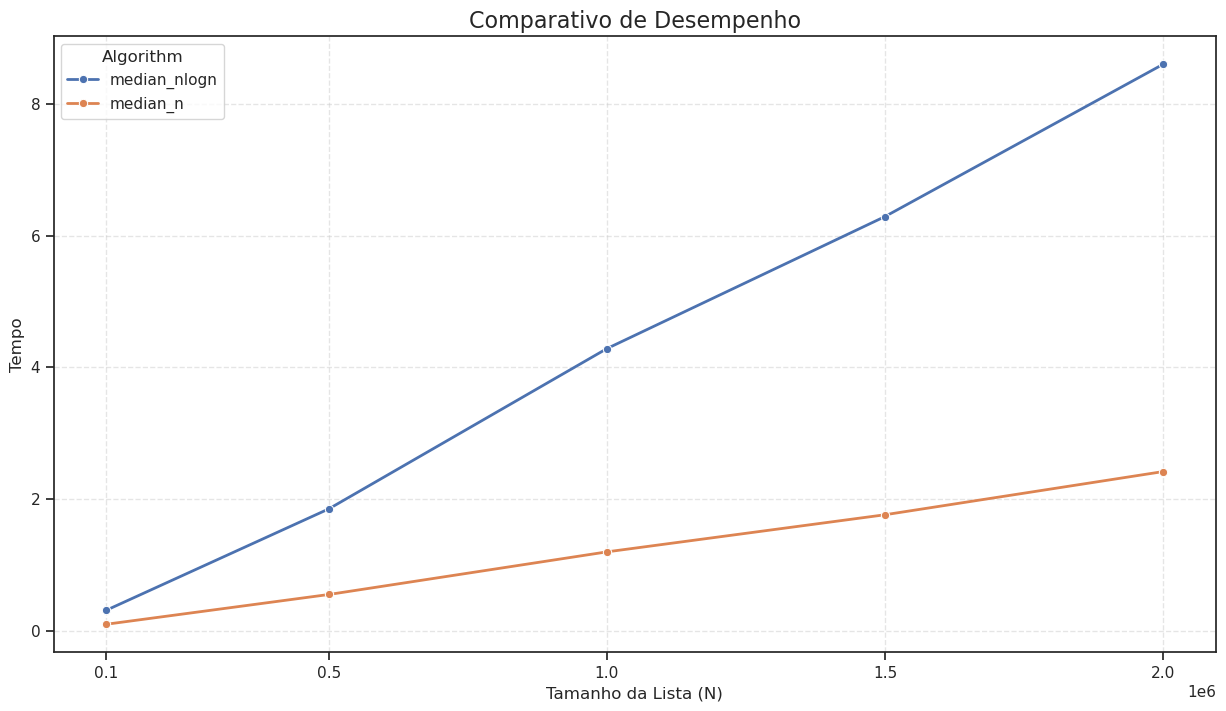

In [170]:
#resultado do experimento
import seaborn as sns
%matplotlib inline
import matplotlib.pyplot as plt

##Defines font size and line width
sns.set(font_scale=1, style="ticks", rc={"lines.linewidth": 2})

##Defines plot size
plt.figure(figsize=(15, 8))

g = sns.lineplot(x='Size', y='Time', hue='Algorithm', data=df, marker="o")
# g.set_yscale('log')
g.set(xticks=sizes)

g.set_title("Comparativo de Desempenho", fontsize=16)
g.set_xlabel("Tamanho da Lista (N)", fontsize=12)
g.set_ylabel("Tempo", fontsize=12)

plt.grid(True, which="both", ls="--", alpha=0.5)
plt.show()